In [1]:
import numpy as np
import matplotlib.pyplot as plt

from torchvision.datasets import OxfordIIITPet

from tqdm.auto import tqdm

from PIL import Image

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

import models
import inference
import utils

In [2]:
category = 15
size = 128
threshold = 0.5

In [3]:
def plot_mask(image, mask):
    mask = np.array(mask)
    masked = np.ma.masked_where(mask == 0, mask)
    plt.imshow(np.array(image))
    plt.imshow(masked, cmap='jet', alpha=0.5)
    plt.axis('off')
    plt.show()
    
def IoU(mask1, mask2):
    mask1 = np.array(mask1, dtype=float)
    mask2 = np.array(mask2, dtype=float)
    intersection = np.logical_and(mask1, mask2)
    union = np.logical_or(mask1, mask2)
    
    return np.sum(intersection) / np.sum(union)

In [4]:
dataset = OxfordIIITPet(
    root="data",
    split="trainval",
    target_types=("segmentation", "category"),
    download=True
)

test_dataset = OxfordIIITPet(
    root="data",
    split="test",
    target_types=("segmentation", "category"),
    download=True
)

In [5]:
def preprocess(mask):
    return mask.point(lambda p: 1 if p == 1 or p == 3 else 0)

def downscale(image, mask, size):
    small_image = image.copy()
    small_image.thumbnail((size,size))
    
    small_mask = mask.copy()
    small_mask.thumbnail((size,size))
    
    image = np.array(small_image)
    mask = np.array(small_mask)
    
    return image, mask

def upscale(image, shape):
    pil_img = Image.fromarray(image)
    up_img = pil_img.resize((shape[0], shape[1]), resample=Image.BILINEAR)
    up_img = np.array(up_img)
    
    return up_img

In [6]:
idx_train = []
for i, (image, (mask, cat)) in tqdm(enumerate(dataset), total=len(dataset)):
    if cat == category:
        idx_train.append(i)

idx_test = []
for i, (image, (mask, cat)) in tqdm(enumerate(test_dataset), total=len(test_dataset)):
    if cat == category:
        idx_test.append(i)

  0%|          | 0/3680 [00:00<?, ?it/s]

  0%|          | 0/3669 [00:00<?, ?it/s]

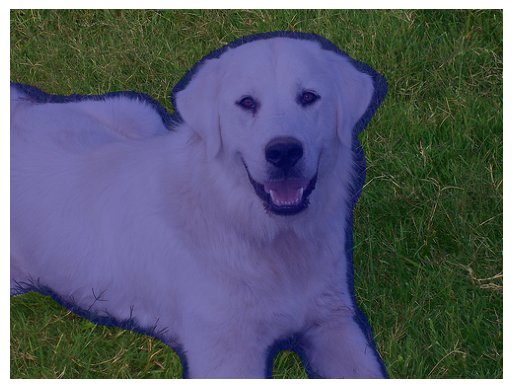

In [7]:
i = 1

image, (mask, cat) = dataset[idx_train[i]]
mask = preprocess(mask)

plot_mask(image, mask)

In [8]:
features = []
labels = []

for i in tqdm(idx_train):
    image, (mask, cat) = dataset[i]
    mask = preprocess(mask)
    image, mask = downscale(image, mask, size)
    mask = mask > threshold
    fg = image[mask]
    features.append(fg)
    labels.append(np.ones(len(fg)))
    bg = image[~mask]
    features.append(bg)
    labels.append(np.zeros(len(bg)))

features = np.concatenate(features)
labels = np.concatenate(labels)

idx_0 = np.where(labels == 0)[0]
idx_1 = np.where(labels == 1)[0]

n = min(len(idx_0), len(idx_1))

idx_0_balanced = np.random.choice(idx_0, size=n, replace=False)
idx_1_balanced = np.random.choice(idx_1, size=n, replace=False)

balanced_idx = np.concatenate([idx_0_balanced, idx_1_balanced])
np.random.shuffle(balanced_idx)

features = features[balanced_idx]
labels = labels[balanced_idx]


  0%|          | 0/100 [00:00<?, ?it/s]

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.5, random_state=42, stratify=labels
)

logisticMask = models.LogisticMask(size, solver="newton-cholesky")
densityMask = models.DensityMask(size)

logisticMask.fit(X_train, y_train)
densityMask.fit(X_train, y_train)

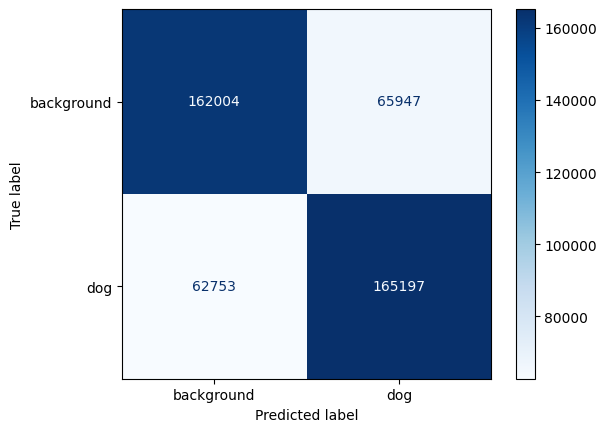

In [ ]:
model = logisticMask

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["background", "dog"])
disp.plot(cmap="Blues")
plt.show()


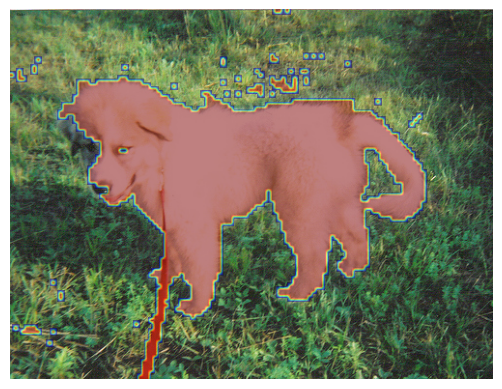

In [11]:
i = 5

image, (mask, cat) = test_dataset[idx_test[i]]
mask = preprocess(mask)
downscaled_image, downscaled_mask = downscale(image, mask, size)

predictions = model.predict_image(downscaled_image)


plot_mask(image, upscale(predictions, image.size))

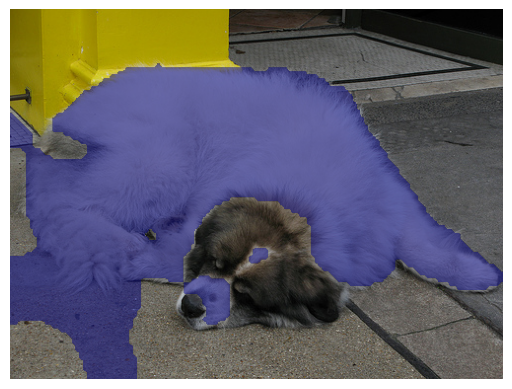

0.6683157118268994


In [12]:
i = 4
max_iter = 50

image, (mask, cat) = test_dataset[idx_test[i]]
mask = preprocess(mask)
downscaled_image, downscaled_mask = downscale(image, mask, size)

predictions = model(downscaled_image, max_iter)
predictions = upscale(predictions, image.size) > threshold

plot_mask(image, predictions)
print(IoU(mask, predictions))

In [14]:
def run_single_image(k, model, max_iter):
    image, (mask, cat) = test_dataset[k]
    mask = preprocess(mask)
    downscaled_image, downscaled_mask = downscale(image, mask, size)

    predictions = model(downscaled_image, max_iter)
    predictions = upscale(predictions, image.size) > threshold
    return IoU(mask, predictions)

def sequential_segmentation(idx, model, max_iter):
    results = []
    for k in tqdm(idx):
        iou = run_single_image(k, model, max_iter)
        results.append(iou)
    return np.array(results)

In [ ]:
ious = sequential_segmentation(idx_test, model, max_iter)
print("Mean IoU:", ious.mean())

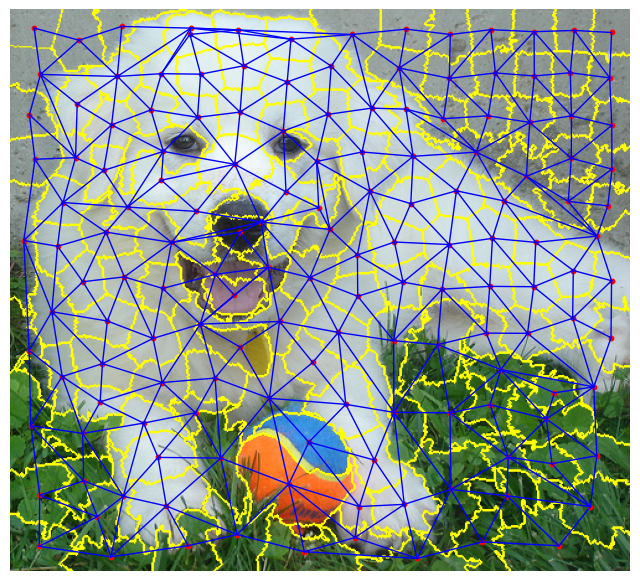

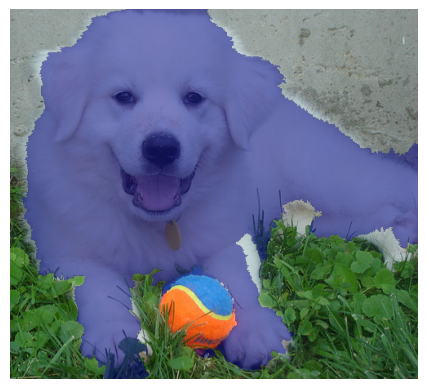

In [18]:
i = 2
image, (mask, cat) = test_dataset[idx_test[i]]
image = np.array(image)
mask = np.array(preprocess(mask))

segments, pixels, edges = utils.get_superpixels(image)
graph = utils.get_super_pixels_graph(model.model, image, 1)

_, labels, super_mask = utils.process_super_pixel(image, mask, segments, pixels)
for i, p in enumerate(pixels):
    super_mask[segments == p] = labels[i]

utils.plot_superpixels(image, segments, edges)
plot_mask(image, super_mask)

In [19]:
features = []
labels = []

for i in tqdm(idx_train):
    image, (mask, cat) = dataset[i]
    mask = preprocess(mask)
    segments, pixels, edges = utils.get_superpixels(image)
    feature, label, _ = utils.process_super_pixel(image, mask, segments, pixels)
    features.append(feature)
    labels.append(label)

features = np.concatenate(features)
labels = np.concatenate(labels)

idx_0 = np.where(labels == 0)[0]
idx_1 = np.where(labels == 1)[0]

n = min(len(idx_0), len(idx_1))

idx_0_balanced = np.random.choice(idx_0, size=n, replace=False)
idx_1_balanced = np.random.choice(idx_1, size=n, replace=False)

balanced_idx = np.concatenate([idx_0_balanced, idx_1_balanced])
np.random.shuffle(balanced_idx)

features = features[balanced_idx]
labels = labels[balanced_idx]


100%|██████████| 100/100 [00:22<00:00,  4.53it/s]


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.2, random_state=42, stratify=labels
)

logisticMask = models.LogisticMask(size)
densityMask = models.DensityMask(size)

logisticMask.fit(X_train, y_train)
densityMask.fit(X_train, y_train)

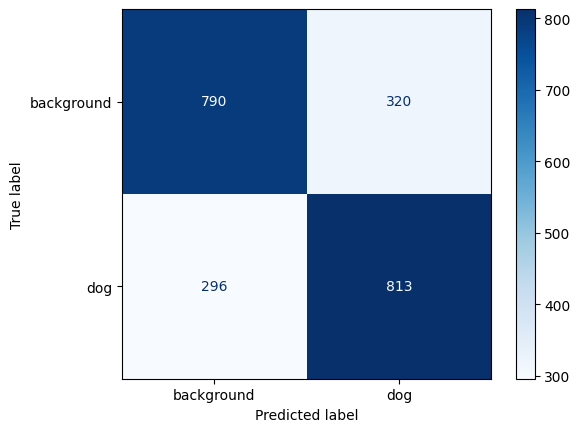

In [25]:
model = logisticMask

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["background", "dog"])
disp.plot(cmap="Blues")
plt.show()

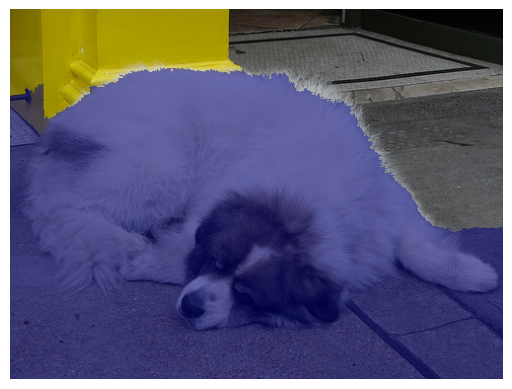

0.6351765716655804


In [31]:
i = 4

image, (mask, cat) = test_dataset[idx_test[i]]
mask = preprocess(mask)

graph = utils.get_super_pixels_graph(model.model, image, 1, transform=model.scaler)
marginals = inference.loopy_bp(graph, 50)

segments, pixels, edges = utils.get_superpixels(image)

predictions = np.zeros_like(mask)
for pixel, label in marginals.items():
    predictions[segments==pixel] = np.argmax(label)
    
plot_mask(image, predictions)
print(IoU(mask, predictions))

In [32]:
def run_single_image(k, model, max_iter):
    image, (mask, cat) = test_dataset[k]
    mask = preprocess(mask)
    graph = utils.get_super_pixels_graph(model.model, image, 1, transform=model.scaler)
    marginals = inference.loopy_bp(graph, 50)

    segments, pixels, edges = utils.get_superpixels(image)

    predictions = np.zeros_like(mask)
    
    for pixel, label in marginals.items():
        predictions[segments==pixel] = np.argmax(label)
    return IoU(mask, predictions)

def sequential_segmentation(idx, model, max_iter):
    results = []
    for k in tqdm(idx):
        iou = run_single_image(k, model, max_iter)
        results.append(iou)
    return np.array(results)

In [33]:
ious = sequential_segmentation(idx_test, model, max_iter)
print("Mean IoU:", ious.mean())

100%|██████████| 100/100 [00:41<00:00,  2.41it/s]

Mean IoU: 0.4751245265421397
